In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')
plt.rcParams["figure.dpi"] = 110

#### 1. LOAD & PERSIAPAN DATA

In [3]:
df = pd.read_csv('AI_Impact_on_Jobs_2030.csv')
df.head()

,Employee_ID,Job_Title,Industry,Country,Education_Level,Years_Experience,AI_Replacement_Risk,Future_Demand_Score,Remote_Work_Possibility,Average_Salary_USD,Required_Skills,Automation_Level,Job_Growth_2030,Work_Hours_Per_Week,Company_Size,AI_Tool_Usage,Performance_Score,Upskilling_Needed,Job_Satisfaction,Hiring_Trend_2026
0,AIJ-100000,Data Engineer,Healthcare,Japan,PhD,1,0.25,0.78,Yes,207392,"Python, Communication, Deep Learning",Low,3,37,Enterprise,High,2.08,Yes,3.86,Growing
1,AIJ-100001,Healthcare Analyst,Retail,UK,Bachelor,24,0.73,0.33,No,140785,"Deep Learning, Azure, Communication, TensorFlo...",Low,-5,42,Startup,Moderate,4.54,No,4.23,Growing
2,AIJ-100002,HR Specialist,Education,Canada,High School,21,0.80,0.69,Yes,124800,"Kubernetes, Cloud Computing, TensorFlow, SQL, ...",Medium,-5,57,Startup,Low,3.14,No,3.54,Stable
3,AIJ-100003,Cybersecurity Analyst,Government,UK,Bachelor,5,0.29,0.94,No,199878,"Excel, Kubernetes, Prompt Engineering, Leadership",Medium,7,59,Enterprise,High,3.67,No,4.37,Declining
4,AIJ-100004,Healthcare Analyst,Education,UAE,PhD,20,0.11,0.92,No,178682,"SQL, Leadership, TensorFlow, Cybersecurity",Low,6,34,Startup,High,3.68,No,3.99,Stable


In [4]:
print("Jumlah Baris & Kolom", df.shape)

Jumlah Baris & Kolom (3000, 20)


In [5]:
print("Tipe data", df.dtypes)

Tipe data Employee_ID                 object
Job_Title                   object
Industry                    object
Country                     object
Education_Level             object
Years_Experience             int64
AI_Replacement_Risk        float64
Future_Demand_Score        float64
Remote_Work_Possibility     object
Average_Salary_USD           int64
Required_Skills             object
Automation_Level            object
Job_Growth_2030              int64
Work_Hours_Per_Week          int64
Company_Size                object
AI_Tool_Usage               object
Performance_Score          float64
Upskilling_Needed           object
Job_Satisfaction           float64
Hiring_Trend_2026           object
dtype: object


In [6]:
print("Total missing value", df.isnull().sum())

Total missing value Employee_ID                0
Job_Title                  0
Industry                   0
Country                    0
Education_Level            0
Years_Experience           0
AI_Replacement_Risk        0
Future_Demand_Score        0
Remote_Work_Possibility    0
Average_Salary_USD         0
Required_Skills            0
Automation_Level           0
Job_Growth_2030            0
Work_Hours_Per_Week        0
Company_Size               0
AI_Tool_Usage              0
Performance_Score          0
Upskilling_Needed          0
Job_Satisfaction           0
Hiring_Trend_2026          0
dtype: int64


In [7]:
print("Total duplikat value", df.duplicated().sum())

Total duplikat value 0


In [8]:
# Pecah kolom required skills
df['Skills_List'] = df['Required_Skills'].apply(
    lambda x: [s.strip() for s in x.split(",")]
)
df["Skills_Count"] = df["Skills_List"].apply(len)

#### 2. STATISTIK DESKRIPTIF

In [9]:
numeric_cols = [
    "Years_Experience", "AI_Replacement_Risk", "Future_Demand_Score",
    "Average_Salary_USD", "Job_Growth_2030", "Work_Hours_Per_Week",
    "Performance_Score", "Job_Satisfaction"
]
print("\n",df[numeric_cols].describe().round(2))


        Years_Experience  AI_Replacement_Risk  Future_Demand_Score  \
count           3000.00              3000.00              3000.00   
mean              12.38                 0.50                 0.60   
std                7.53                 0.26                 0.23   
min                0.00                 0.05                 0.20   
25%                6.00                 0.28                 0.42   
50%               12.00                 0.50                 0.60   
75%               19.00                 0.73                 0.80   
max               25.00                 0.95                 0.99   

       Average_Salary_USD  Job_Growth_2030  Work_Hours_Per_Week  \
count             3000.00          3000.00              3000.00   
mean            126641.75            17.24                44.77   
std              55405.05            16.23                 8.93   
min              30221.00           -10.00                30.00   
25%              77262.00             3.0

In [10]:
corr = df[numeric_cols].corr()
print("===================Matriks Korelasi===================")
print(corr.round(2))

===================Matriks Korelasi===================
                     Years_Experience  AI_Replacement_Risk  \
Years_Experience                 1.00                -0.03   
AI_Replacement_Risk             -0.03                 1.00   
Future_Demand_Score             -0.05                 0.01   
Average_Salary_USD               0.01                -0.01   
Job_Growth_2030                 -0.02                 0.00   
Work_Hours_Per_Week             -0.01                 0.00   
Performance_Score                0.02                -0.01   
Job_Satisfaction                 0.02                 0.02   

                     Future_Demand_Score  Average_Salary_USD  Job_Growth_2030  \
Years_Experience                   -0.05                0.01            -0.02   
AI_Replacement_Risk                 0.01               -0.01             0.00   
Future_Demand_Score                 1.00                0.01             0.05   
Average_Salary_USD                  0.01                1.00  

#### 3. INSIGHT 1: Risiko Otomatisasi (AI_Replacement_Risk) per Pekerjaan

In [11]:
risk_by_job = (
    df.groupby('Job_Title')['AI_Replacement_Risk']
    .mean()
    .sort_values(ascending=False)
)

In [12]:
print("TOP 10 Pekerjaan Dengan Risiko Penggantian AI Tertinggi")
print(risk_by_job.head(10).round(3))

TOP 10 Pekerjaan Dengan Risiko Penggantian AI Tertinggi
Job_Title
DevOps Engineer          0.569
Cloud Architect          0.564
IoT Specialist           0.527
Prompt Engineer          0.522
Teacher                  0.520
Healthcare Analyst       0.518
Data Engineer            0.517
Cybersecurity Analyst    0.510
Robotics Engineer        0.507
Blockchain Developer     0.506
Name: AI_Replacement_Risk, dtype: float64


In [13]:
print("TOP 10 Pekerjaan Dengan Risiko Penggantian AI Tertinggi")
print(risk_by_job.tail(10).round(3))

TOP 10 Pekerjaan Dengan Risiko Penggantian AI Tertinggi
Job_Title
Software Developer           0.497
HR Specialist                0.492
Digital Marketer             0.489
Product Manager              0.486
Financial Analyst            0.485
AI Engineer                  0.476
Business Analyst             0.473
Machine Learning Engineer    0.472
Data Scientist               0.470
UX Designer                  0.460
Name: AI_Replacement_Risk, dtype: float64


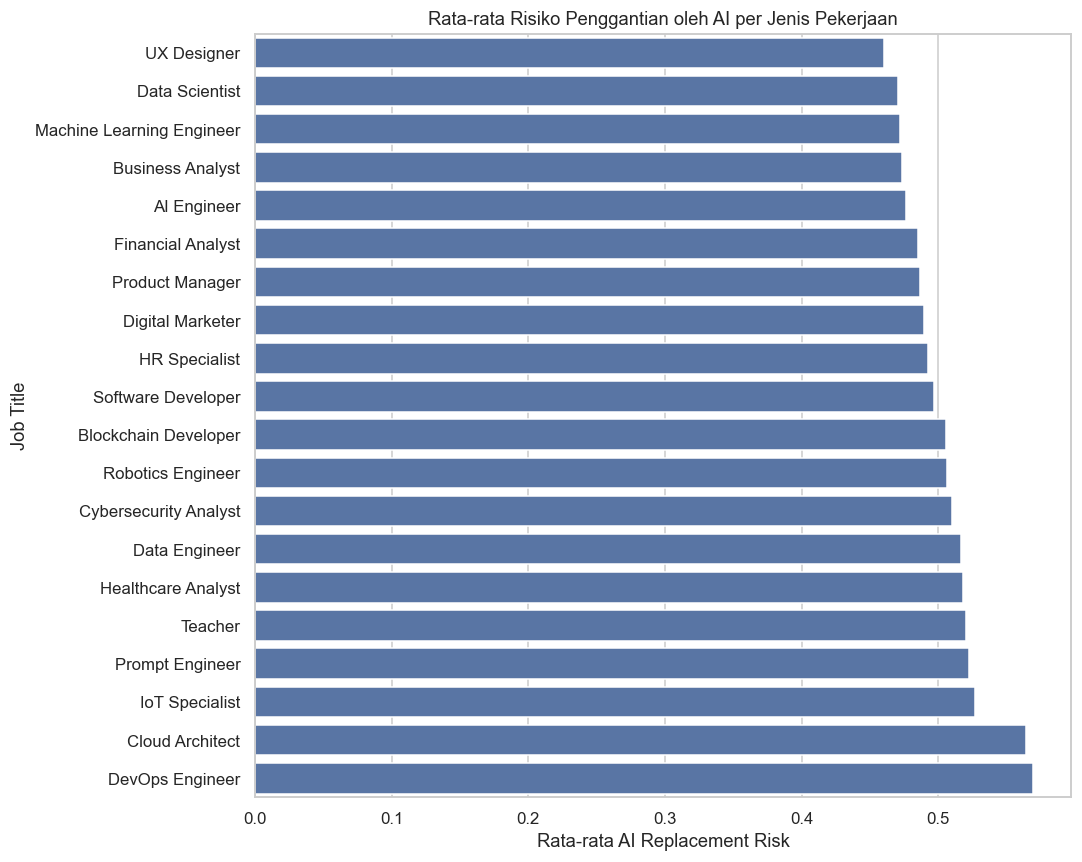

In [36]:
plt.figure(figsize=(10, 8))
order = risk_by_job.sort_values(ascending=True).index
sns.barplot(
    x = risk_by_job.reindex(order).values,
    y = order
)
plt.xlabel("Rata-rata AI Replacement Risk")
plt.ylabel("Job Title")
plt.title("Rata-rata Risiko Penggantian oleh AI per Jenis Pekerjaan")
plt.tight_layout()
plt.savefig('01_risk_by_job.png', dpi=400)
plt.show()

#### 4. INSIGHT 2: Future Demand Score vs AI Replacement Risk per Industri

In [15]:
industry_summary = (
    df.groupby('Industry')[['AI_Replacement_Risk', 'Future_Demand_Score']]
    .mean()
    .sort_values('Future_Demand_Score', ascending=False)
)

In [16]:
print("\n========== Rata-rata Risk & Demand per Industri ==========\n")
print(industry_summary.round(3))


========== Rata-rata Risk & Demand per Industri ==========

                AI_Replacement_Risk  Future_Demand_Score
Industry                                                
Government                    0.529                0.621
Healthcare                    0.475                0.613
Finance                       0.530                0.611
Manufacturing                 0.496                0.605
Education                     0.497                0.599
Retail                        0.496                0.598
Energy                        0.499                0.596
Technology                    0.517                0.593
Media                         0.490                0.590
Transportation                0.494                0.585


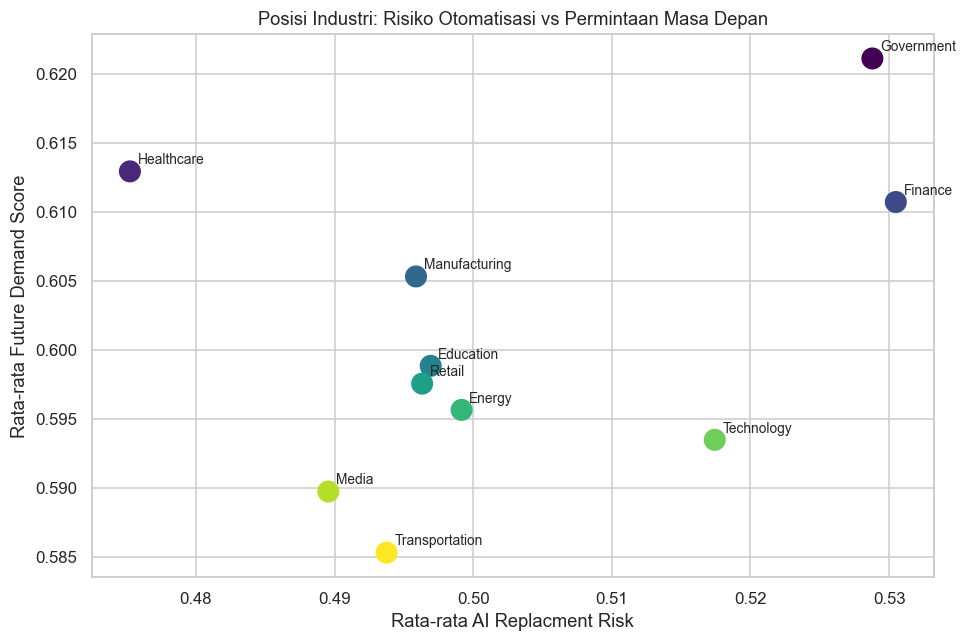

In [38]:
plt.figure(figsize=(9, 6))
plt.scatter(
    industry_summary['AI_Replacement_Risk'],
    industry_summary['Future_Demand_Score'],
    s=180,
    c=range(len(industry_summary)),
    cmap='viridis'
)
for idx, row in industry_summary.iterrows():
    plt.annotate(idx, (row['AI_Replacement_Risk'], row['Future_Demand_Score']),
                 textcoords='offset points', xytext=(5,5), fontsize=9)

plt.xlabel("Rata-rata AI Replacment Risk")
plt.ylabel("Rata-rata Future Demand Score")
plt.title("Posisi Industri: Risiko Otomatisasi vs Permintaan Masa Depan")
plt.tight_layout()
plt.savefig('02_industry_risk_vs_demand.png', dpi=400)
plt.show()

#### 5. INSIGHT 3: Hubungan Gaji dengan Risiko AI dan Demand

In [18]:
print("===Korelasi Average Salary USD dengan variabel lain===\n")
print(corr['Average_Salary_USD'].sort_values(ascending=False).round(3))

===Korelasi Average Salary USD dengan variabel lain===

Average_Salary_USD     1.000
Job_Satisfaction       0.018
Years_Experience       0.013
Future_Demand_Score    0.005
AI_Replacement_Risk   -0.007
Performance_Score     -0.010
Job_Growth_2030       -0.012
Work_Hours_Per_Week   -0.012
Name: Average_Salary_USD, dtype: float64


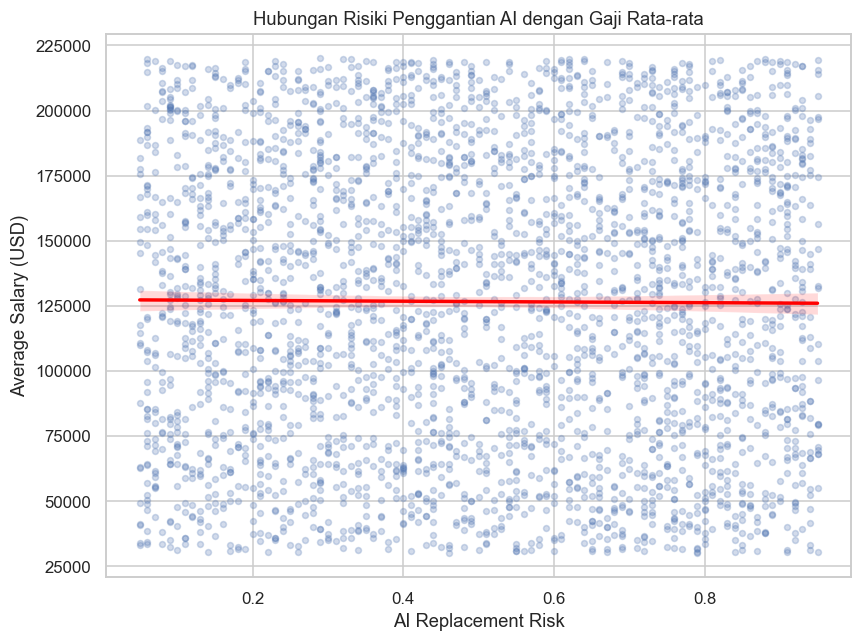

In [39]:
plt.figure(figsize=(8, 6))
sns.regplot(
    data=df,
    x = 'AI_Replacement_Risk',
    y = 'Average_Salary_USD',
    scatter_kws={'alpha':.25, 's':15,},
    line_kws={'color':'red'}
)
plt.title("Hubungan Risiki Penggantian AI dengan Gaji Rata-rata")
plt.xlabel("AI Replacement Risk")
plt.ylabel("Average Salary (USD)")
plt.tight_layout()
plt.savefig('03_salary_vs_risk.png', dpi=400)
plt.show()

#### 6. INSIGHT 4: Dampak Upskilling terhadap Job Satisfaction & Demand

In [20]:
upskill_sumary = df.groupby('Upskilling_Needed')[
    ['Job_Satisfaction', 'Future_Demand_Score', 'AI_Replacement_Risk', 'Average_Salary_USD']
].mean()
print("=====Perbandingan berdasarkan Kebutuhan Upskilling=====")
print(upskill_sumary.round(3))

=====Perbandingan berdasarkan Kebutuhan Upskilling=====
                   Job_Satisfaction  Future_Demand_Score  AI_Replacement_Risk  \
Upskilling_Needed                                                               
No                            3.058                0.600                0.508   
Yes                           2.994                0.602                0.498   

                   Average_Salary_USD  
Upskilling_Needed                      
No                         126149.029  
Yes                        127141.744  


C:\Users\Solit\AppData\Local\Temp\ipykernel_11536\533433714.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(data=df, x='Upskilling_Needed', y='Job_Satisfaction', palette='Set2')


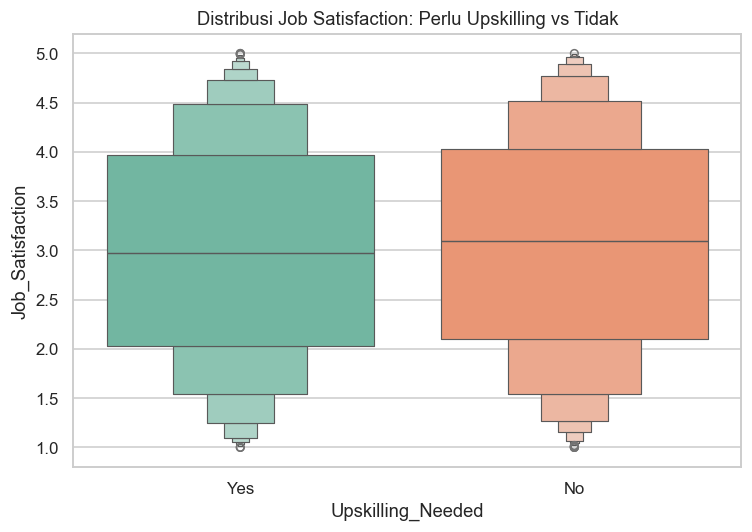

In [40]:
plt.figure(figsize=(7, 5))
sns.boxenplot(data=df, x='Upskilling_Needed', y='Job_Satisfaction', palette='Set2')
plt.title('Distribusi Job Satisfaction: Perlu Upskilling vs Tidak')
plt.tight_layout()
plt.savefig('04_upskilling_satisfaction.png', dpi=400)
plt.show()

#### 7. INSIGHT 5: Tren Hiring 2026 berdasarkan Automation Level

In [22]:
hiring_cross = pd.crosstab(
    df['Automation_Level'],
    df['Hiring_Trend_2026'],
    normalize='index')*100
print("=====Presentase Hiring Trend 2026 per Tingkat Otomatisasi (%)=====\n")
print(hiring_cross.round(3))

=====Presentase Hiring Trend 2026 per Tingkat Otomatisasi (%)=====

Hiring_Trend_2026  Declining  Growing  Stable
Automation_Level                             
High                  33.403   33.824  32.773
Low                   31.051   34.233  34.716
Medium                33.630   32.938  33.432


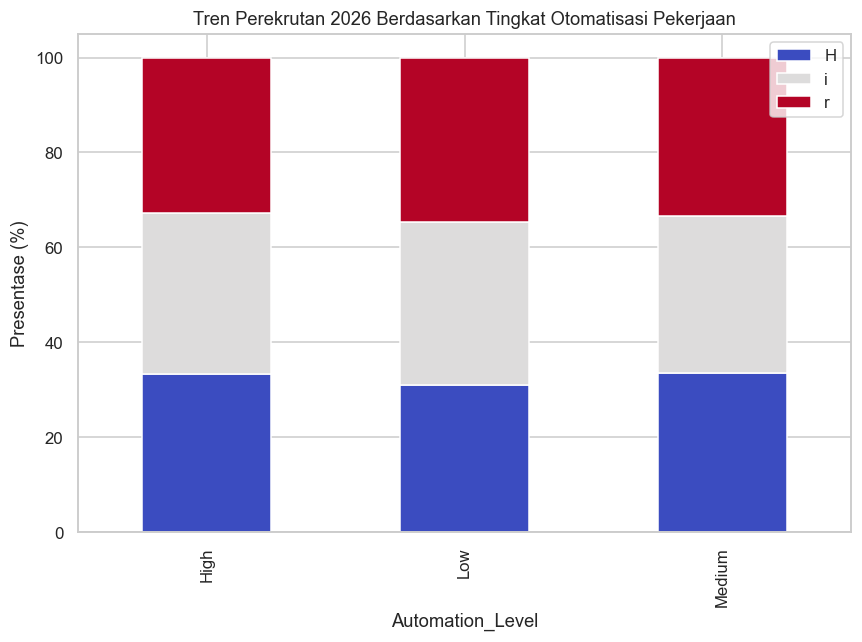

In [41]:
hiring_cross.plot(kind='bar', stacked=True, figsize=(8,6), colormap='coolwarm')
plt.ylabel("Presentase (%)")
plt.title("Tren Perekrutan 2026 Berdasarkan Tingkat Otomatisasi Pekerjaan")
plt.legend("Hiring Trend 2026")
plt.tight_layout()
plt.savefig('05_hiring_trend_by_automation.png', dpi=400)
plt.show()

#### 8. INSIGHT 6: Pengaruh Remote Work Possibility terhadap Job Satisfaction

In [24]:
remote_summary = df.groupby('Remote_Work_Possibility')[
    ['Job_Satisfaction', 'Work_Hours_Per_Week', 'Average_Salary_USD']
].mean()
print("=====Perbandingan berdasarkan Kemungkinan Remote Work=====")
print(remote_summary.round(2))

=====Perbandingan berdasarkan Kemungkinan Remote Work=====
                         Job_Satisfaction  Work_Hours_Per_Week  \
Remote_Work_Possibility                                          
Hybrid                               3.04                44.96   
No                                   3.02                44.81   
Yes                                  3.02                44.56   

                         Average_Salary_USD  
Remote_Work_Possibility                      
Hybrid                            127970.09  
No                                129054.30  
Yes                               122931.15  


C:\Users\Solit\AppData\Local\Temp\ipykernel_11536\874591330.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Remote_Work_Possibility', y='Job_Satisfaction', palette='muted')


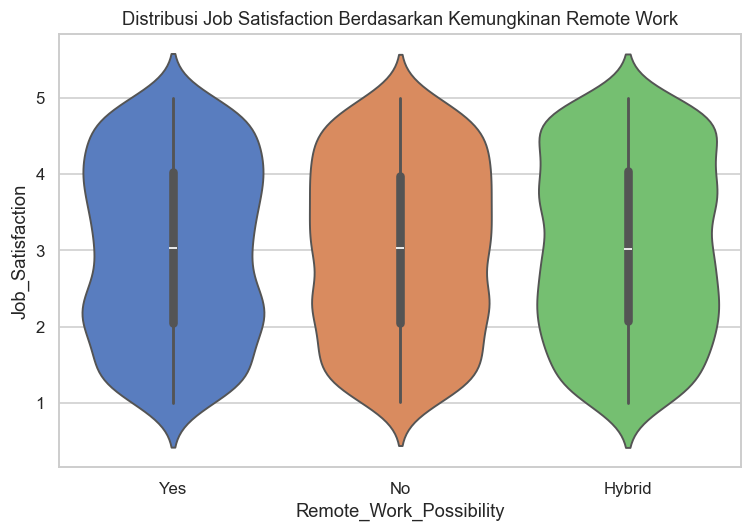

In [42]:
plt.figure(figsize=(7, 5))
sns.violinplot(data=df, x='Remote_Work_Possibility', y='Job_Satisfaction', palette='muted')
plt.title('Distribusi Job Satisfaction Berdasarkan Kemungkinan Remote Work')
plt.tight_layout()
plt.savefig('06_remote_satisfaction.png', dpi=400)
plt.show()

#### 9. INSIGHT 7: Skill yang paling sering dibutuhkan

In [26]:
all_skills = df['Skills_List'].explode()
skill_count = all_skills.value_counts()
print("=====Skills Yang Paling Banyka Dibutuhkan=====")
skill_count.head(10)

=====Skills Yang Paling Banyka Dibutuhkan=====


Skills_List
Cloud Computing       785
Leadership            778
Cybersecurity         776
Communication         776
Azure                 772
Deep Learning         770
Machine Learning      765
TensorFlow            762
Data Visualization    751
Kubernetes            750
Name: count, dtype: int64

C:\Users\Solit\AppData\Local\Temp\ipykernel_11536\1622507276.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=skill_count.head(15).values, y=skill_count.head(15).index, palette='crest')


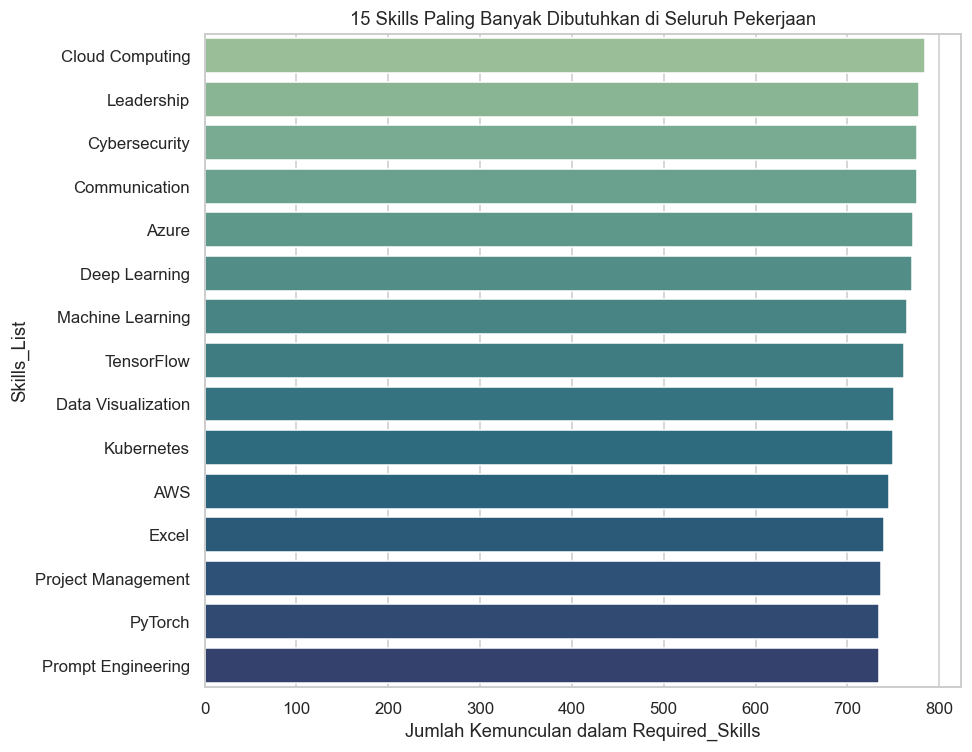

In [43]:
plt.figure(figsize=(9, 7))
sns.barplot(x=skill_count.head(15).values, y=skill_count.head(15).index, palette='crest')
plt.title('15 Skills Paling Banyak Dibutuhkan di Seluruh Pekerjaan')
plt.xlabel('Jumlah Kemunculan dalam Required_Skills')
plt.tight_layout()
plt.savefig('07_top_skills.png', dpi=400)
plt.show()

##### Skill apa yang berasosiasi dengan risiko AI rendah (<0.3)?

In [28]:
low_risk_skills = df[df['AI_Replacement_Risk'] < 0.3]['Skills_List'].explode().value_counts()
high_risk_skills = df[df['AI_Replacement_Risk']>0.7]['Skills_List'].explode().value_counts()

print("=====TOP 10 Skills Pada Pekerjaan Risiko Renda digantikan AI=====")
print(low_risk_skills.tail(10))
print("\n=====TOP 10 Skills Pada Pekerjaan Risiko Renda digantikan AI=====")
print(high_risk_skills.head(10))

=====TOP 10 Skills Pada Pekerjaan Risiko Renda digantikan AI=====
Skills_List
Data Visualization    203
Project Management    203
AWS                   202
Prompt Engineering    200
SQL                   198
Kubernetes            198
TensorFlow            191
Python                189
Docker                177
PyTorch               177
Name: count, dtype: int64

=====TOP 10 Skills Pada Pekerjaan Risiko Renda digantikan AI=====
Skills_List
Leadership            235
Deep Learning         232
Cybersecurity         230
TensorFlow            229
Project Management    226
AWS                   223
Communication         219
Prompt Engineering    217
Machine Learning      214
Kubernetes            214
Name: count, dtype: int64


#### 10. INSIGHT 8: Pengaruh Tingkat Pendidikan

In [29]:
edu_order = ["High School", "Bachelor", "Master", "PhD"]

edu_summary = df.groupby('Education_Level')[
    ['Average_Salary_USD', 'AI_Replacement_Risk', 'Future_Demand_Score', 'Job_Satisfaction']
].mean().reindex(edu_order)
print("=====Rata-rata Metrik berdasarkan Tingkat Pendidikan=====")
print(edu_summary.round(2))

=====Rata-rata Metrik berdasarkan Tingkat Pendidikan=====
                 Average_Salary_USD  AI_Replacement_Risk  Future_Demand_Score  \
Education_Level                                                                 
High School               128510.33                 0.51                 0.61   
Bachelor                  128001.97                 0.50                 0.60   
Master                    124825.22                 0.51                 0.59   
PhD                       125192.73                 0.50                 0.60   

                 Job_Satisfaction  
Education_Level                    
High School                  3.14  
Bachelor                     3.05  
Master                       2.93  
PhD                          2.99  


C:\Users\Solit\AppData\Local\Temp\ipykernel_11536\1610950769.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=edu_summary.index, y=edu_summary['Average_Salary_USD'], ax=axes[0], palette='Blues_d')
C:\Users\Solit\AppData\Local\Temp\ipykernel_11536\1610950769.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=edu_summary.index, y=edu_summary['AI_Replacement_Risk'], ax=axes[1], palette='Reds_d')


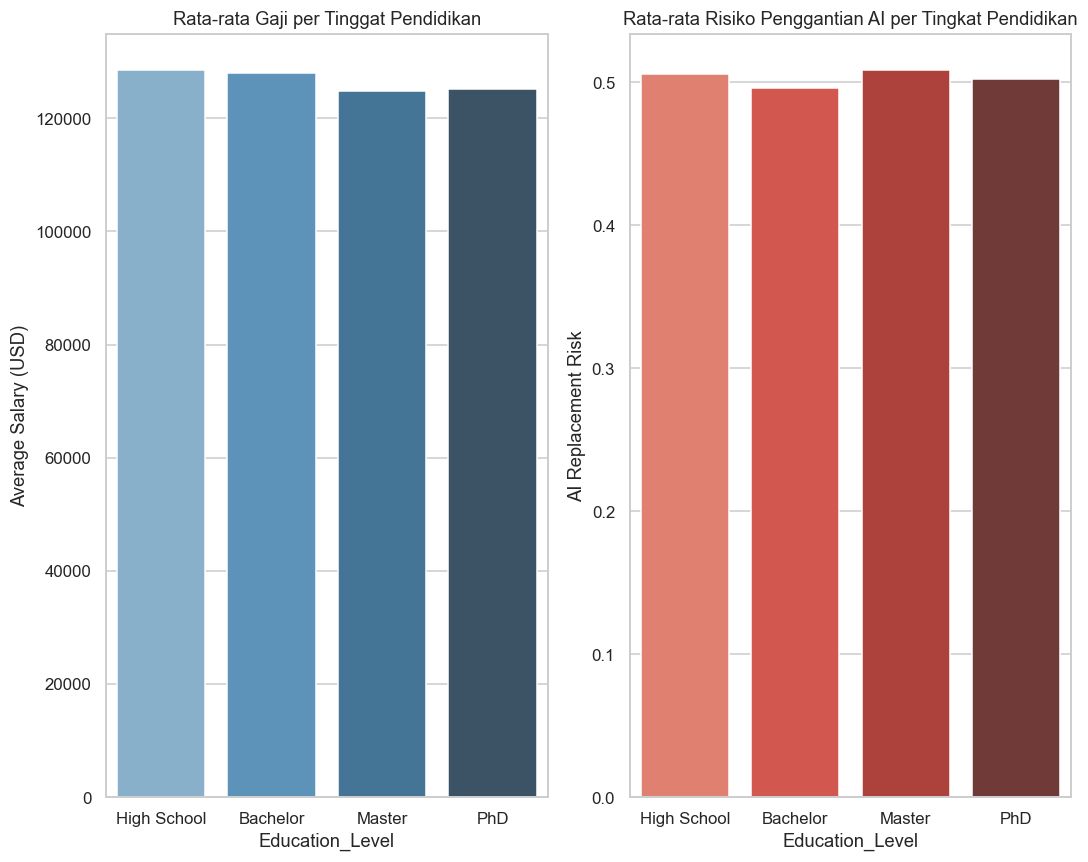

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(10, 8))
sns.barplot(x=edu_summary.index, y=edu_summary['Average_Salary_USD'], ax=axes[0], palette='Blues_d')
axes[0].set_title('Rata-rata Gaji per Tinggat Pendidikan')
axes[0].set_ylabel('Average Salary (USD)')

sns.barplot(x=edu_summary.index, y=edu_summary['AI_Replacement_Risk'], ax=axes[1], palette='Reds_d')
axes[1].set_title('Rata-rata Risiko Penggantian AI per Tingkat Pendidikan')
axes[1].set_ylabel('AI Replacement Risk')

plt.tight_layout()
plt.savefig('08_education_salary_risk.png', dpi=400)
plt.show()

#### 11. INSIGHT 9: Perbandingan Negara (Country)

In [31]:
country_summary = df.groupby('Country')[
    ['Average_Salary_USD', 'AI_Replacement_Risk', 'Future_Demand_Score']
].mean().sort_values(by='Average_Salary_USD', ascending=False)

print("===========Rata-rata Avg Salary, Risk, Demand per Negara===========")
print(country_summary.round(2))

===========Rata-rata Avg Salary, Risk, Demand per Negara===========
           Average_Salary_USD  AI_Replacement_Risk  Future_Demand_Score
Country                                                                
UK                  133214.81                 0.50                 0.60
Singapore           130980.43                 0.48                 0.60
Australia           129039.27                 0.50                 0.60
Germany             128440.74                 0.51                 0.60
UAE                 126109.20                 0.51                 0.61
India               125810.67                 0.50                 0.60
USA                 124013.86                 0.50                 0.62
Canada              123726.45                 0.50                 0.58
Pakistan            122865.55                 0.53                 0.60
Japan               122355.13                 0.51                 0.61


C:\Users\Solit\AppData\Local\Temp\ipykernel_11536\3172423965.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=country_summary['Average_Salary_USD'], y=country_summary.index, palette='mako')


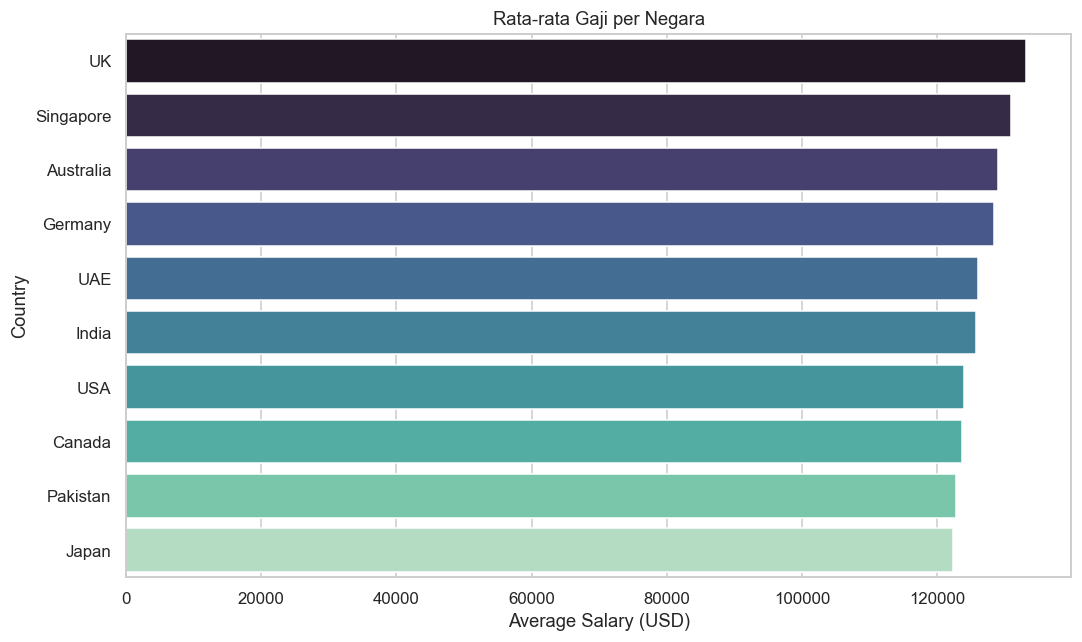

In [45]:
plt.figure(figsize=(10, 6))
sns.barplot(x=country_summary['Average_Salary_USD'], y=country_summary.index, palette='mako')
plt.title('Rata-rata Gaji per Negara')
plt.xlabel('Average Salary (USD)')
plt.tight_layout()
plt.savefig('09_salary_by_country.png', dpi=400)
plt.show()

#### 12. INSIGHT 10: Heatmap Korelasi Keseluruhan

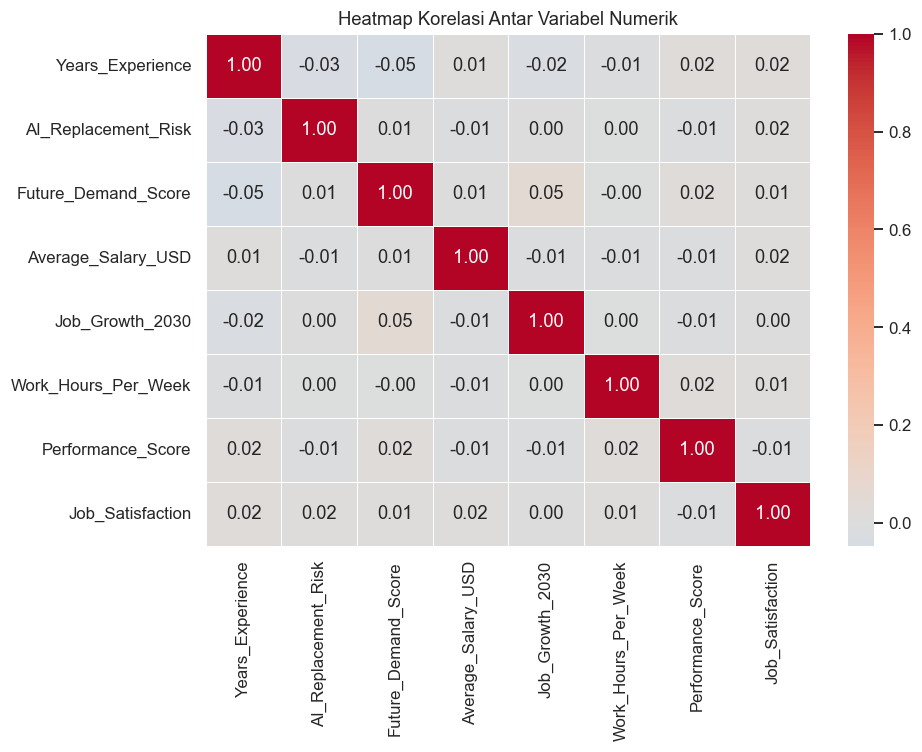

In [46]:
plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=.5)
plt.title('Heatmap Korelasi Antar Variabel Numerik')
plt.tight_layout()
plt.savefig('10_correlation_heatmap.png', dpi=400)
plt.show()

#### 13. INSIGHT 11: Job_Growth_2030 - pekerjaan paling tumbuh & paling menyusut

In [34]:
growt_by_job = df.groupby('Job_Title')['Job_Growth_2030'].mean().sort_values(ascending=False)
print("=====TOP 5 Pekerjaan dengan Proyeksi Pertumbuhan Tertinggi (2030)=====")
print(growt_by_job.head().round(2))

=====TOP 5 Pekerjaan dengan Proyeksi Pertumbuhan Tertinggi (2030)=====
Job_Title
Blockchain Developer    18.94
Software Developer      18.60
Healthcare Analyst      18.54
Data Scientist          18.43
Data Engineer           17.86
Name: Job_Growth_2030, dtype: float64


##### Menggunakan np.where untuk membuat kategori risk tinggi/menengah/rendah (contoh penggunaan NumPy)

In [35]:
df['Risk_Category'] = np.where(
    df['AI_Replacement_Risk'] >= 0.7, 'Tinggi',
    np.where(df['AI_Replacement_Risk'] >= 0.4, 'Menengah', 'Rendah')
)

print('Distribusi Kategory Risiko')
print(df['Risk_Category'].value_counts())

Distribusi Kategory Risiko
Risk_Category
Rendah      1138
Menengah     975
Tinggi       887
Name: count, dtype: int64
